In [ ]:
import pathlib

In [ ]:
import marimo as mo
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats as sps
import seaborn as sns
from teeplot import teeplot as tp
from watermark import watermark

In [ ]:
mo.md(
    f"""
```Text
{watermark(
    current_date=True,
    iso8601=True,
    machine=True,
    updated=True,
    python=True,
    iversions=True,
    globals_=globals(),
)}
```
"""
)

```Text
Last updated: 2026-06-18T18:28:51.659156+00:00

Python implementation: CPython
Python version       : 3.10.12
IPython version      : 7.31.1

Compiler    : GCC 11.4.0
OS          : Linux
Release     : 6.8.0-1059-azure
Machine     : x86_64
Processor   : x86_64
CPU cores   : 4
Architecture: 64bit

seaborn   : 0.13.2
scipy     : 1.14.1
numpy     : 2.1.2
matplotlib: 3.10.7
pandas    : 2.2.3
teeplot   : 1.4.2
marimo    : 0.23.2

```

## Data

The **2-site** companion to
`bindle/2026-06-17-3site-mutation-sweep.py`. Load the per-replicate
Hamming-weight **end-state** table produced by the 2-site
mutation-rate sweep slurm job
(`slurm/2026-06-17/2026-06-17-2site-mutation-sweep.sh`, driven by
notebook `bindle/2026-05-20-founder.py`). The sweep fixes `N_SITES=2`
(genomes `00, 01, 10, 11`, Hamming weights `0 .. 2`) and steps
`MUTATION_RATE` across all 17 conditions spanning `1e-9` to `1e-1`
(~2 points per decade) at 200 replicates each, 5000 steps per
replicate, POP_SIZE=1_000_000, on CPU (engine=numpy).

The `hw-final` frame --- one row per `(replicate_uid, hw)` at the
final simulation step recording the per-Hamming-weight number of
cases (`n_cases`), alongside the swept `mutation_rate` --- is read
from the **committed local parquet** under
`bindle/data/2026-06-18-2site-mutation-sweep/` (checked into the repo
during an OSF outage), so this notebook needs no network access.

In [ ]:
# Read the committed local hw-final parquet (checked into the repo
# under bindle/data/<job>/ during an OSF outage) --- no network.
_job = "2026-06-18-2site-mutation-sweep"
_path = (
    pathlib.Path(__file__).parent
    / "data"
    / _job
    / f"a=hw-final+date=2026-06-18+job={_job}+ext=.pqt"
)
print(f"loading {_path.name}")
hw_df = pd.read_parquet(_path)
print(f"loaded hw dataframe: {hw_df.shape}")
print(
    "mutation_rate x replicate counts:\n"
    + str(hw_df.groupby("mutation_rate")["replicate_uid"].nunique()),
)

loading a=hw-final+date=2026-06-18+job=2026-06-18-2site-mutation-sweep+ext=.pqt
loaded hw dataframe: (10176, 20)
mutation_rate x replicate counts:
mutation_rate
1.000000e-09    200
3.000000e-09    199
1.000000e-08    199
3.000000e-08    200
1.000000e-07    200
               ... 
1.000000e-03    200
3.000000e-03    196
1.000000e-02    200
3.000000e-02    200
1.000000e-01    200
Name: replicate_uid, Length: 17, dtype: int64


## Fixation Outcome per Replicate

For each replicate, take its **last simulation step** and identify
the **dominant Hamming-weight class** by case count (`n_cases`) ---
the Hamming-weight bin that has "fixed" as the most-populous strain
cluster at end-state, following the coarse strain identifier used in
the founder-convergence analyses.

With `N_SITES=2` the four genomes split into three Hamming-weight
classes, which we group into two outcomes:

- **founder strain (00/11)**: Hamming weights `0` and `2`, i.e. the
  all-zero founder/wildtype genome and its bitwise complement
  (`hw in {0, 2}`, 2 of the 4 genomes).
- **HW 1 (intermediate)**: Hamming weight `1`, the one-mutation
  genomes `01` and `10` that are bitwise complements of one another
  (`hw == 1`, the other 2 of the 4 genomes).

We classify each replicate's end-state into one of these two
categories, then ask how the **probability of the founder strain
fixing** (vs. the intermediate HW 1 class fixing) depends on the
swept `mutation_rate`.

In [ ]:
_n_sites = int(hw_df["n_sites"].iloc[0])

# Restrict to each replicate's final step (n_steps is constant within
# a replicate, but compute per-replicate to be safe).
_last_steps = hw_df.groupby("replicate_uid")["Step"].transform("max")
_last = hw_df[hw_df["Step"] == _last_steps]

# Dominant (most-populous) Hamming-weight class per replicate at the
# final step. idxmax breaks ties toward the lower hw, which is fine
# for a coarse fixed-strain label.
_dom_idx = _last.groupby("replicate_uid")["n_cases"].idxmax()
outcome_df = _last.loc[
    _dom_idx,
    ["replicate_uid", "mutation_rate", "hw"],
].copy()

# Founder strain (00/11) == extreme Hamming weights {0, N_SITES};
# HW 1 intermediate == the middle weight {1}.
outcome_df["group"] = outcome_df["hw"].map(
    lambda _hw: "founder (00/11)"
    if _hw in (0, _n_sites)
    else "HW 1 (intermediate)",
)
print(f"outcome frame: {outcome_df.shape}")
print(
    "dominant hw class counts:\n"
    + str(outcome_df["hw"].value_counts().sort_index()),
)
print(
    "group counts:\n" + str(outcome_df["group"].value_counts()),
)

outcome frame: (3392, 4)
dominant hw class counts:
hw
0     656
1    2137
2     599
Name: count, dtype: int64
group counts:
group
HW 1 (intermediate)    2137
founder (00/11)        1255
Name: count, dtype: int64


## Exact (Clopper-Pearson) 95% Confidence Intervals

For each `mutation_rate` the fixation outcome is a Bernoulli trial
per replicate (founder strain fixes or not), so the per-condition
fraction of replicates is a **binomial proportion**. We summarize it
with the **exact Clopper-Pearson interval** via
`scipy.stats.binomtest(k, n).proportion_ci(method="exact")` --- an
exact estimator CI inverted from the binomial CDF, **not** a
bootstrap. The complementary "HW 1 (intermediate)" series uses the
same exact construction on the `n - k` complementary successes, so
its interval is the exact CI for that proportion (and is not merely a
reflection of the founder interval).

In [ ]:
_groups = ["founder (00/11)", "HW 1 (intermediate)"]
_rows = []
for _mr, _sub in outcome_df.groupby("mutation_rate"):
    _n = len(_sub)
    _k_founder = int((_sub["group"] == "founder (00/11)").sum())
    _k_by_group = {
        "founder (00/11)": _k_founder,
        "HW 1 (intermediate)": _n - _k_founder,
    }
    for _group in _groups:
        _k = _k_by_group[_group]
        _ci = sps.binomtest(_k, _n).proportion_ci(
            confidence_level=0.95,
            method="exact",
        )
        _rows.append(
            {
                "mutation_rate": float(_mr),
                "group": _group,
                "n_fixed": _k,
                "n_total": _n,
                "p": _k / _n,
                "ci_low": float(_ci.low),
                "ci_high": float(_ci.high),
            },
        )

summary_df = (
    pd.DataFrame(_rows)
    .sort_values(
        ["group", "mutation_rate"],
    )
    .reset_index(drop=True)
)
print(summary_df.to_string(index=False))

 mutation_rate               group  n_fixed  n_total        p   ci_low  ci_high
  1.000000e-09 HW 1 (intermediate)      107      200 0.535000 0.463300 0.605647
  3.000000e-09 HW 1 (intermediate)      123      199 0.618090 0.546719 0.685887
  1.000000e-08 HW 1 (intermediate)      134      199 0.673367 0.603469 0.738008
  3.000000e-08 HW 1 (intermediate)      179      200 0.895000 0.843981 0.933819
  1.000000e-07 HW 1 (intermediate)      186      200 0.930000 0.885340 0.961204
  3.000000e-07 HW 1 (intermediate)      155      200 0.775000 0.710760 0.830897
  1.000000e-06 HW 1 (intermediate)       65      200 0.325000 0.260626 0.394654
  3.000000e-06 HW 1 (intermediate)        2      200 0.010000 0.001213 0.035655
  1.000000e-05 HW 1 (intermediate)        0      198 0.000000 0.000000 0.018458
  3.000000e-05 HW 1 (intermediate)        2      200 0.010000 0.001213 0.035655
  1.000000e-04 HW 1 (intermediate)        5      200 0.025000 0.008166 0.057374
  3.000000e-04 HW 1 (intermediate)      

## Fixation Probability vs. Mutation Rate

`seaborn` lineplot of the per-condition fixation probability against
`mutation_rate` on a **log x-axis**, one line per outcome group. The
shaded **band shows the exact (Clopper-Pearson) 95% confidence
interval** computed above (seaborn's own bootstrap CI is disabled
via `errorbar=None`; the band is drawn from the exact estimator).
The dashed **horizontal rule at 50%** marks the chance expectation
that one of the two founder-aligned genomes (00/11, 2 of the 4
possible 2-site genomes) fixes under a uniform-over-genomes null.

teeplots/2026-06-17-2site-mutation-sweep/a=founder-vs-hw1-fixation-prob+hue=group+marker=o+viz=lineplot+x=mutation-rate+y=p+ext=.pdf
teeplots/2026-06-17-2site-mutation-sweep/a=founder-vs-hw1-fixation-prob+hue=group+marker=o+viz=lineplot+x=mutation-rate+y=p+ext=.png


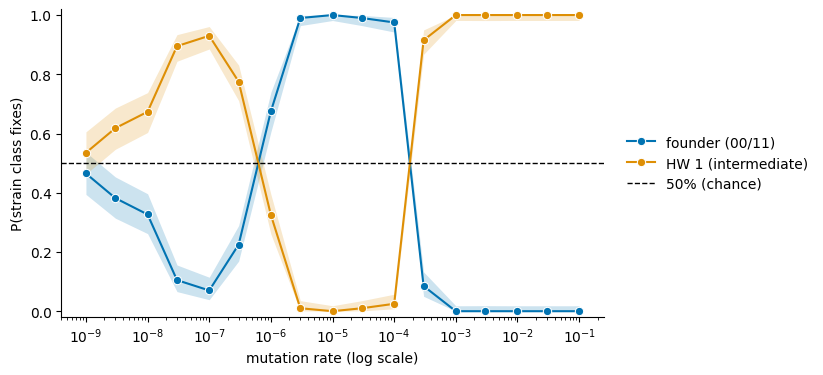

In [ ]:
_groups = ["founder (00/11)", "HW 1 (intermediate)"]
_palette = dict(
    zip(_groups, sns.color_palette("colorblind", n_colors=len(_groups))),
)

with tp.teed(
    sns.lineplot,
    data=summary_df,
    x="mutation_rate",
    y="p",
    hue="group",
    hue_order=_groups,
    palette=_palette,
    marker="o",
    errorbar=None,
    teeplot_outattrs={"a": "founder-vs-hw1-fixation-prob"},
    teeplot_show=True,
    teeplot_subdir=pathlib.Path(__file__).stem,
) as _ax:
    # Exact-CI band per group (fill_between, not bootstrap).
    for _group in _groups:
        _sub = summary_df[summary_df["group"] == _group].sort_values(
            "mutation_rate",
        )
        _ax.fill_between(
            _sub["mutation_rate"],
            _sub["ci_low"],
            _sub["ci_high"],
            color=_palette[_group],
            alpha=0.2,
            linewidth=0,
        )
    # Chance expectation for the founder pair (2 of 4 genomes).
    _ax.axhline(
        0.50,
        color="black",
        linestyle="--",
        linewidth=1.0,
        label="50% (chance)",
    )
    _ax.set_xscale("log")
    _ax.set_ylim(-0.02, 1.02)
    _ax.set_xlabel("mutation rate (log scale)")
    _ax.set_ylabel("P(strain class fixes)")
    _ax.legend(
        title=None,
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        frameon=False,
    )
    sns.despine(ax=_ax)
    _ax.figure.set_size_inches(7, 4)

## Probability & 95% CI Table

Per-`mutation_rate` fixation probability with the exact
Clopper-Pearson 95% confidence interval, for both outcome groups.
`n_fixed` / `n_total` are the binomial counts behind each estimate.

In [ ]:
_table_df = (
    summary_df.assign(
        p=summary_df["p"].round(4),
        ci_low=summary_df["ci_low"].round(4),
        ci_high=summary_df["ci_high"].round(4),
        ci_95=summary_df.apply(
            lambda _r: f"[{_r['ci_low']:.3f}, {_r['ci_high']:.3f}]",
            axis=1,
        ),
    )[
        [
            "group",
            "mutation_rate",
            "n_fixed",
            "n_total",
            "p",
            "ci_low",
            "ci_high",
            "ci_95",
        ]
    ]
    .sort_values(["group", "mutation_rate"])
    .reset_index(drop=True)
)

print(_table_df.to_string(index=False))
mo.ui.table(_table_df, selection=None)

              group  mutation_rate  n_fixed  n_total      p  ci_low  ci_high          ci_95
HW 1 (intermediate)   1.000000e-09      107      200 0.5350  0.4633   0.6056 [0.463, 0.606]
HW 1 (intermediate)   3.000000e-09      123      199 0.6181  0.5467   0.6859 [0.547, 0.686]
HW 1 (intermediate)   1.000000e-08      134      199 0.6734  0.6035   0.7380 [0.603, 0.738]
HW 1 (intermediate)   3.000000e-08      179      200 0.8950  0.8440   0.9338 [0.844, 0.934]
HW 1 (intermediate)   1.000000e-07      186      200 0.9300  0.8853   0.9612 [0.885, 0.961]
HW 1 (intermediate)   3.000000e-07      155      200 0.7750  0.7108   0.8309 [0.711, 0.831]
HW 1 (intermediate)   1.000000e-06       65      200 0.3250  0.2606   0.3947 [0.261, 0.395]
HW 1 (intermediate)   3.000000e-06        2      200 0.0100  0.0012   0.0357 [0.001, 0.036]
HW 1 (intermediate)   1.000000e-05        0      198 0.0000  0.0000   0.0185 [0.000, 0.018]
HW 1 (intermediate)   3.000000e-05        2      200 0.0100  0.0012   0.0357 [0.

,group,mutation_rate,n_fixed,n_total,p,ci_low,ci_high,ci_95
0,HW 1 (intermediate),1.000000e-09,107,200,0.5350,0.4633,0.6056,"[0.463, 0.606]"
1,HW 1 (intermediate),3.000000e-09,123,199,0.6181,0.5467,0.6859,"[0.547, 0.686]"
2,HW 1 (intermediate),1.000000e-08,134,199,0.6734,0.6035,0.7380,"[0.603, 0.738]"
3,HW 1 (intermediate),3.000000e-08,179,200,0.8950,0.8440,0.9338,"[0.844, 0.934]"
4,HW 1 (intermediate),1.000000e-07,186,200,0.9300,0.8853,0.9612,"[0.885, 0.961]"
...,...,...,...,...,...,...,...,...
29,founder (00/11),1.000000e-03,0,200,0.0000,0.0000,0.0183,"[0.000, 0.018]"
30,founder (00/11),3.000000e-03,0,196,0.0000,0.0000,0.0186,"[0.000, 0.019]"
31,founder (00/11),1.000000e-02,0,200,0.0000,0.0000,0.0183,"[0.000, 0.018]"
32,founder (00/11),3.000000e-02,0,200,0.0000,0.0000,0.0183,"[0.000, 0.018]"
